In [7]:
%%capture
! pip install seaborn

In [4]:
!pip install openpyxl

     ---------------------------------------- 0.0/250.0 kB ? eta -:--:--
     - -------------------------------------- 10.2/250.0 kB ? eta -:--:--
     ---- -------------------------------- 30.7/250.0 kB 325.1 kB/s eta 0:00:01
     ------------- ----------------------- 92.2/250.0 kB 655.4 kB/s eta 0:00:01
     ---------------------- ------------- 153.6/250.0 kB 833.5 kB/s eta 0:00:01
     -------------------------------------- 250.0/250.0 kB 1.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 23.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import openpyxl as xl

Load_Data = pd.ExcelFile('DL (NR) 22-23.xlsx')
data_22_23 = Load_Data.parse('DL (NR)')
data_23_24 = Load_Data.parse('DL(NR) FY 23-24')
data_23_24.tail()


In [15]:
# find the column number of the column named 3/31/2023 '
col_num = 0
for i in range(0, len(data_23_24.columns), -1):
    if data_23_24.columns[i] == '3/31/2023 00:00:00 ':
        col_num = i
        break

In [16]:
col_num

0

In [12]:
col_num = len(data_23_24.columns) - col_num

In [19]:
# print the column of column number
print(data_23_24.columns[367])

FY 2023-24


In [20]:
Finaldata = data_22_23.iloc[:, :366]

In [21]:

# concat data_23_24 from col 2 in Finaldata
Finaldata_1 = pd.concat([Finaldata, data_23_24.iloc[:, 2:]], axis=1)

In [27]:
# save Finaldata_1 to excel
Finaldata_1.iloc[:, 368]

0          Monday
1      Actual(MW)
2        10.48576
3         11.8834
4        12.67572
          ...    
100       7.93084
101       26.8252
102           NaN
103           NaN
104      39.22527
Name: 2023-04-03 00:00:00, Length: 105, dtype: object

In [28]:
data = Finaldata_1

In [29]:
data.shape

(105, 750)

In [30]:
# 105th row is the last row of the data
last_row = data.iloc[:105]

In [31]:
last_row.iloc[:98, :]

,Index,Time,2022-04-01 00:00:00,2022-04-02 00:00:00,2022-04-03 00:00:00,2022-04-04 00:00:00,2022-04-05 00:00:00,2022-04-06 00:00:00,2022-04-07 00:00:00,2022-04-08 00:00:00,...,2023-10-01 00:00:00.1,2023-11-01 00:00:00.1,2023-12-01 00:00:00.1,2024-01-01 00:00:00.1,2024-02-01 00:00:00.1,2024-02-29 00:00:00.1,Apr'23-Jun'23,Jul'23-Sep'23,Oct'23-Dec'23,Jan'24-Feb'24
0,NaN,NaN,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Monday,...,Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW)
1,NaN,NaN,Actual(MW),Actual(MW),Actual(MW),Actual(MW),Actual(MW),Actual(MW),Actual(MW),Actual(MW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,00:15:00,16.07,13.08,14.79,15.7,15.34,13.19,10.05,12.2,...,,,,,,,14.541533,17.279358,,
3,2.0,00:30:00,13.75,12.35,13.89,12.38,6.72,13.95,8.14,12.27,...,,,,,,,13.358129,17.096715,,
4,3.0,00:45:00,13.13,8.73,17.1,15.55,8.74,15.41,12.03,11.49,...,,,,,,,13.041758,16.868046,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,92.0,23:00:00,17.89,17.8,17.34,13.19,20.64,17.69,14.49,16.75,...,,,,,,,18.471318,22.088296,,
94,93.0,23:15:00,15.58,17,23.52,16.67,20.32,16.65,12.92,16.39,...,,,,,,,18.349211,22.65916,,
95,94.0,23:30:00,15,16.11,21.33,13.81,17.94,14.01,13.08,20.24,...,,,,,,,16.404974,20.848077,,
96,95.0,23:45:00,14.99,20.08,22.2,18.65,13.32,16.11,12.05,14.95,...,,,,,,,15.865433,19.30713,,


In [32]:
# drop Index column
last_row = last_row.drop(columns=['Index'])

In [33]:
# drop the second row
last_row = last_row.drop([1])

In [34]:
last_row

,Time,2022-04-01 00:00:00,2022-04-02 00:00:00,2022-04-03 00:00:00,2022-04-04 00:00:00,2022-04-05 00:00:00,2022-04-06 00:00:00,2022-04-07 00:00:00,2022-04-08 00:00:00,2022-04-09 00:00:00,...,2023-10-01 00:00:00.1,2023-11-01 00:00:00.1,2023-12-01 00:00:00.1,2024-01-01 00:00:00.1,2024-02-01 00:00:00.1,2024-02-29 00:00:00.1,Apr'23-Jun'23,Jul'23-Sep'23,Oct'23-Dec'23,Jan'24-Feb'24
0,NaN,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Monday,Tuesday,...,Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW),Average Actual (MW)
2,00:15:00,16.07,13.08,14.79,15.7,15.34,13.19,10.05,12.2,13.08,...,,,,,,,14.541533,17.279358,,
3,00:30:00,13.75,12.35,13.89,12.38,6.72,13.95,8.14,12.27,12.54,...,,,,,,,13.358129,17.096715,,
4,00:45:00,13.13,8.73,17.1,15.55,8.74,15.41,12.03,11.49,12.33,...,,,,,,,13.041758,16.868046,,
5,01:00:00,10.36,10.18,16.63,14.29,8.25,10.13,10.8,12.15,10.53,...,,,,,,,12.642298,16.698139,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,NaN,8.57,8.17,9.86,12.38,6.72,9.21,7.95,10.86,9.27,...,0,0,0,0,0,0,10.830476,13.476059,0,0
101,NaN,25.78,26.02,26.13,24.19,27.75,27.5,27.02,31.71,24.89,...,0,0,0,0,0,0,23.585015,28.008142,0,0
102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# get  the index of the column with date 3/31/2023 use date time to convert it to a date time object 
import datetime
index = last_row.columns.get_loc(datetime.datetime(2023, 8, 31, 0, 0))

index

517

In [37]:
final_data = last_row.iloc[:97, :index+1]

In [43]:
final_data.iloc[:, 517]

0      Thursday
2     23.613726
3     23.228344
4      18.96679
5     16.315386
        ...    
93     22.18119
94     21.25662
95    21.041825
96    19.013268
97    16.989035
Name: 2023-08-31 00:00:00, Length: 97, dtype: object

In [38]:
final_data.iloc[1:3,1:]

,2022-04-01,2022-04-02,2022-04-03,2022-04-04,2022-04-05,2022-04-06,2022-04-07,2022-04-08,2022-04-09,2022-04-10,...,2023-08-22,2023-08-23,2023-08-24,2023-08-25,2023-08-26,2023-08-27,2023-08-28,2023-08-29,2023-08-30,2023-08-31
2,16.07,13.08,14.79,15.7,15.34,13.19,10.05,12.2,13.08,8.66,...,16.416057,19.186738,16.889581,19.296702,17.852352,18.267621,15.967826,16.56463,19.693836,23.613726
3,13.75,12.35,13.89,12.38,6.72,13.95,8.14,12.27,12.54,9.42,...,17.072104,16.163786,15.923213,21.47563,14.573744,13.028725,16.418829,18.729867,16.025006,23.228344


In [39]:

final_data.columns.__len__

<bound method Index.__len__ of Index([             'Time', 2022-04-01 00:00:00, 2022-04-02 00:00:00,
       2022-04-03 00:00:00, 2022-04-04 00:00:00, 2022-04-05 00:00:00,
       2022-04-06 00:00:00, 2022-04-07 00:00:00, 2022-04-08 00:00:00,
       2022-04-09 00:00:00,
       ...
       2023-08-22 00:00:00, 2023-08-23 00:00:00, 2023-08-24 00:00:00,
       2023-08-25 00:00:00, 2023-08-26 00:00:00, 2023-08-27 00:00:00,
       2023-08-28 00:00:00, 2023-08-29 00:00:00, 2023-08-30 00:00:00,
       2023-08-31 00:00:00],
      dtype='object', length=518)>

In [44]:
# save the final data to a xlsx file save date timecolumn from col 1 to end as date time object
columns = []
for i in range(1,index+1):
    columns.append( pd.to_datetime(final_data.columns[i]))
final_data.to_excel('new_data.xlsx')
final_data.to_csv('new_data.csv')

In [45]:
# for each time stamp in the column extend it to 15 min interval for each dat
import numpy as np
import pandas as pd
import datetime
import os
import csv
# write a function that will take a date time object and return a list of 15 min interval in that day from 00:00:15 to 00:00:00
def get_Data(date_time):
    data = []
    for i in range(1,97):
        data.append(date_time + datetime.timedelta(minutes=15*i))
    return data
data = get_Data(columns[0])
for i in range(1,columns.__len__()):
    data.extend(get_Data(columns[i]))

In [46]:
# last term of the data is 3/31/2023 23:45:00
data[-1]

Timestamp('2023-09-01 00:00:00')

In [47]:
# in the final data we have 97 columns and 365 rows 
# write a function that will traverse through the final data and add the data to the list starting from the first column first row to the last column last row
def get_Data_from_final_data(final_data):
    data = []
    for i in range(1,final_data.shape[1]):
        for j in range(1,final_data.shape[0]):
            data.append(final_data.iloc[j,i])
    return data

In [48]:
load_data = get_Data_from_final_data(final_data)

In [49]:
load_data[-1]

16.9890352

In [50]:
# make a df with data and load data with data as date time object and load data as float and data is the index
df = pd.DataFrame({'data':data, 'load_data':load_data})
df

,data,load_data
0,2022-04-01 00:15:00,16.070000
1,2022-04-01 00:30:00,13.750000
2,2022-04-01 00:45:00,13.130000
3,2022-04-01 01:00:00,10.360000
4,2022-04-01 01:15:00,9.960000
...,...,...
49627,2023-08-31 23:00:00,22.181190
49628,2023-08-31 23:15:00,21.256620
49629,2023-08-31 23:30:00,21.041825
49630,2023-08-31 23:45:00,19.013268


In [51]:
# set data as index
df = df.set_index('data')

In [52]:
# save data as date time object
df.index = pd.to_datetime(df.index)

In [53]:

df['date'] = df.index

In [54]:
df['date'] = df['date'].dt.strftime("%Y-%m-%d %H:%M:%S")
df['date']= pd.to_datetime(df['date'])

In [55]:
df['day'] = df['date'].dt.day_name()

In [56]:
saving_data = df

saving_data= saving_data.reset_index()
saving_data['index'] = saving_data.index + 1
df.rename(columns={'index':'SlNo'}, inplace=True)

# Write DataFrame to Excel
df.to_excel('final_output.xlsx', index=False)
df.to_csv('final_output.csv', index=False)



In [36]:
# drop date column

df2 = df.drop(columns=['day'])

In [37]:
# rename the load_data column to load
df2 = df2.rename(columns={'load_data':'load'})

In [38]:
# last row of the data
df.tail()
df.head()

,load_data,date,day
data,,,
2022-04-01 00:15:00,16.07,2022-04-01 00:15:00,Friday
2022-04-01 00:30:00,13.75,2022-04-01 00:30:00,Friday
2022-04-01 00:45:00,13.13,2022-04-01 00:45:00,Friday
2022-04-01 01:00:00,10.36,2022-04-01 01:00:00,Friday
2022-04-01 01:15:00,9.96,2022-04-01 01:15:00,Friday


In [39]:
import plotly.graph_objects as go
import pandas as pd
import nbformat

# Assuming you have a DataFrame 'df' with 'Date' and 'Value' columns
df = pd.DataFrame({
    'Date': pd.date_range(start='1/1/2020', end='1/08/2020'),
    'Value': [i for i in range(8)]
})

fig = go.Figure(data=go.Scatter(x=df2.index, y=df2['load'], mode='lines+markers'))

fig.update_layout(
    title="Interactive Time Series Plot",
    xaxis_title="Date",
    yaxis_title="Value",
    autosize=False,
    width=2000,
    height=500,
)

fig.show()


Text(0, 0.5, 'Load Data')

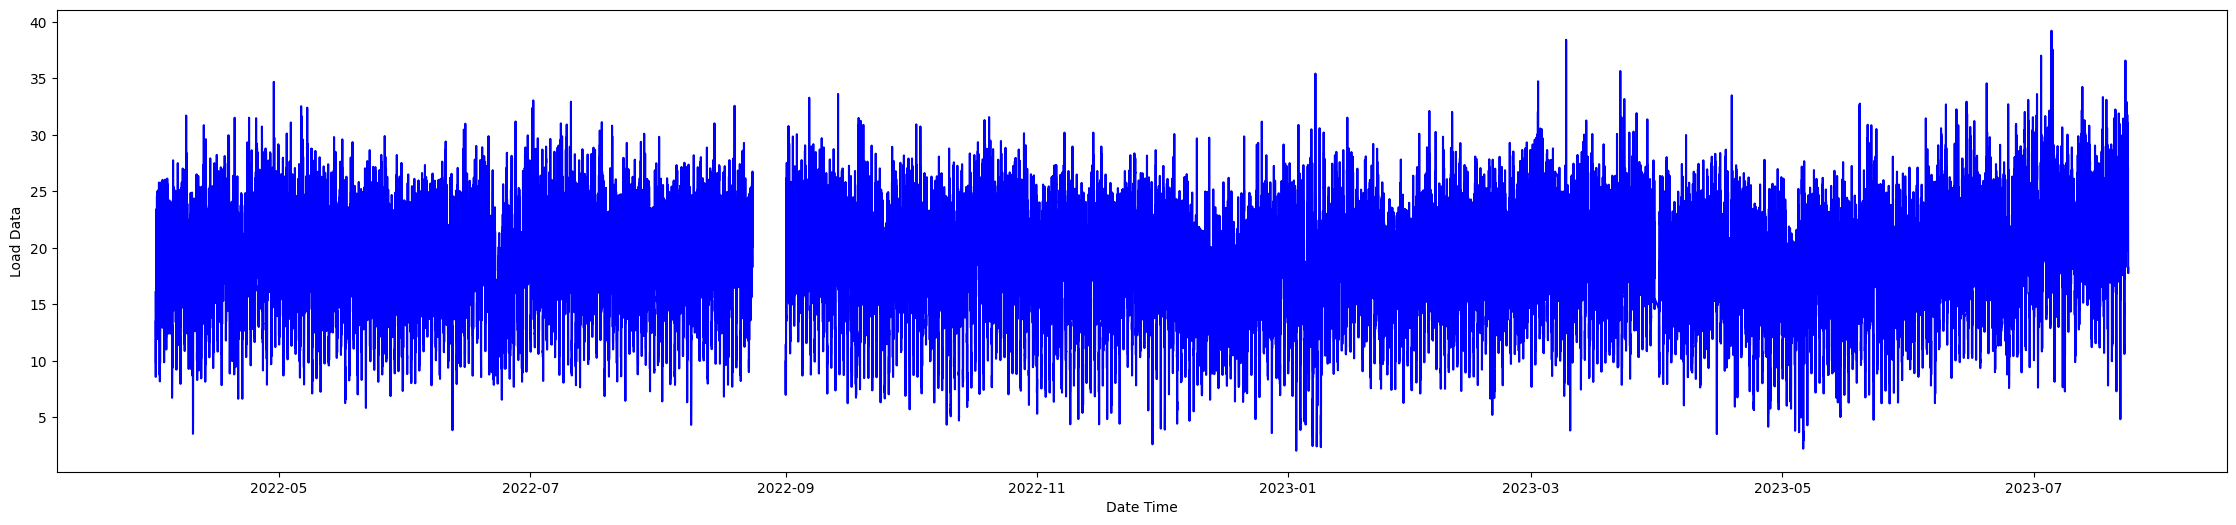

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(28,6))
plt.plot(df2.index, df2['load'], color='blue')
plt.xlabel('Date Time')
plt.ylabel('Load Data')

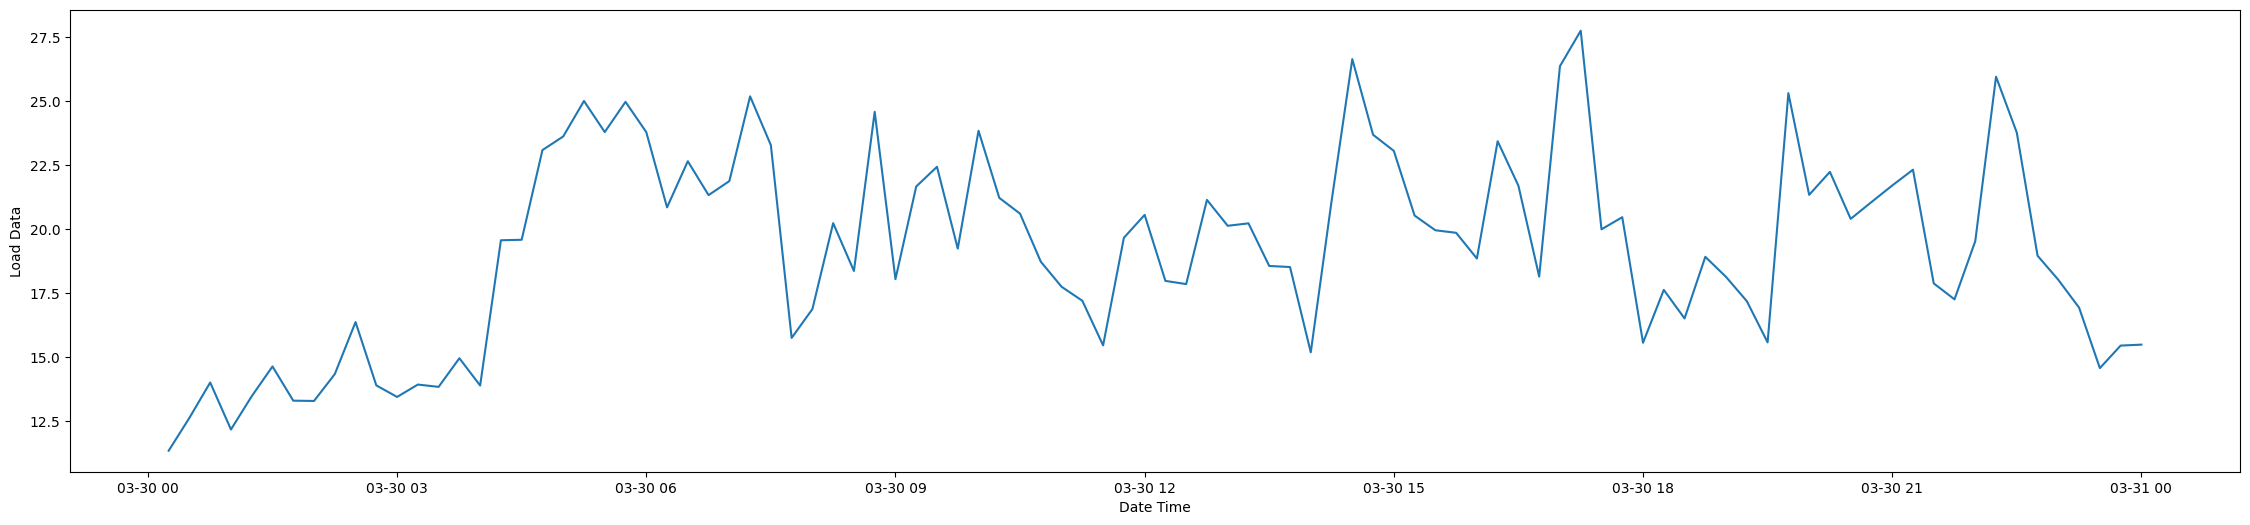

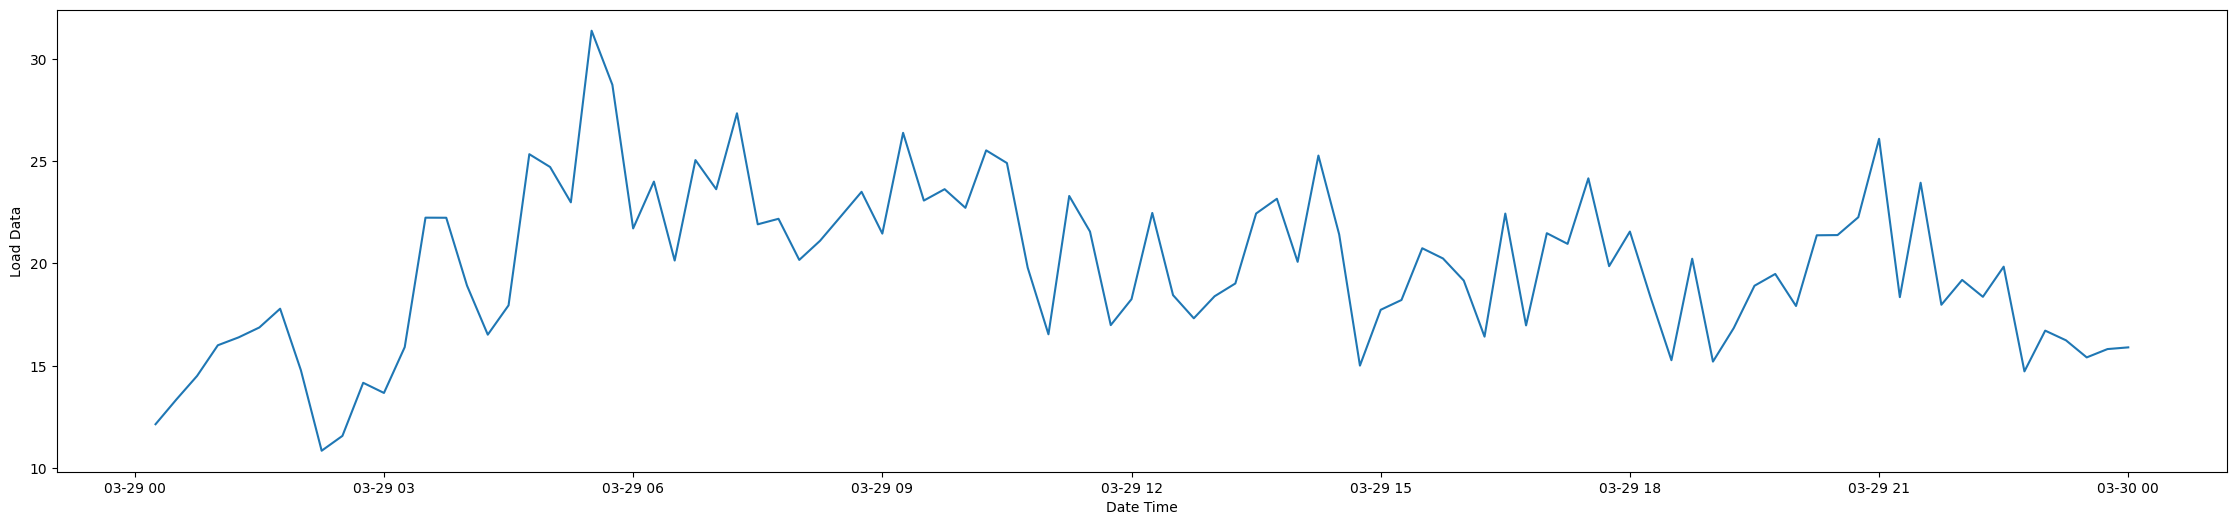

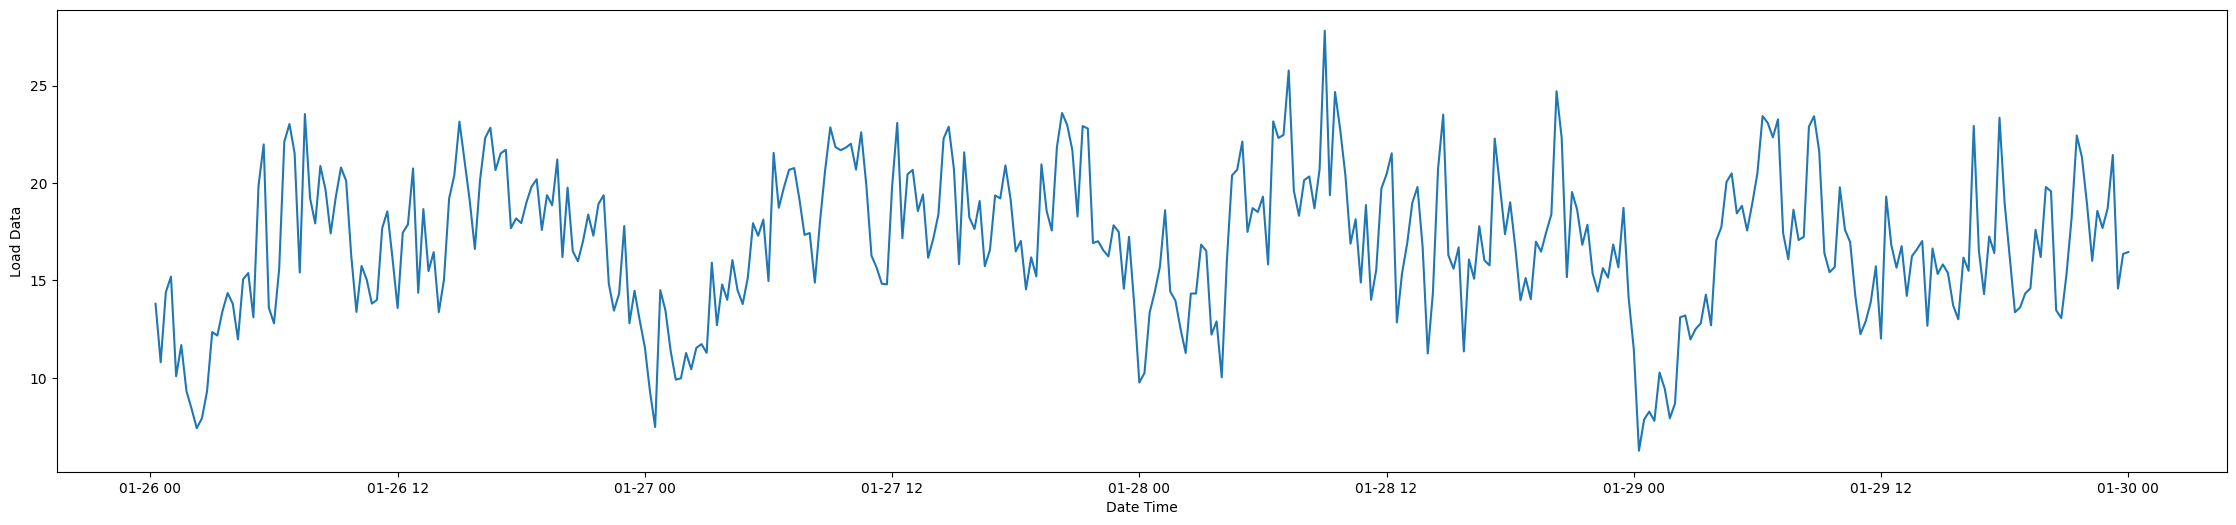

In [55]:
# plot the data in the df on a graph with date time object as x axis and load data as y axis size of the graph 20,10 and color of the graph is blue and plot for one week and save the graph as png file

import seaborn as sns

 
# plot the data in the df on a graph with date time object as x axis and load data as y axis size of the graph 20,10 and color of the graph is blue and plot for one week and save the graph as png file
def plot_data(df, start_date, end_date, file_name, columns=['load']):
    df = df.loc[start_date:end_date]
    plt.figure(figsize=(28,6))
    # how to set different color for different columns
    
    plt.plot(df.index, df[columns]  )
    plt.xlabel('Date Time')
    plt.ylabel('Load Data')
    plt.savefig(file_name)
    plt.show()
    return df
# df_week = plot_data(df2, '2023-03-25 ', '2023-03-31', 'week.png')
# df_month = plot_data(df2, '2023-03-01', '2023-03-31', 'month.png')
df_day = plot_data(df2, '2023-03-30 00:15:00', '2023-03-31 00:00:00', 'day_1.png')
df_day = plot_data(df2, '2023-03-29 00:15:00', '2023-03-30 00:00:00', 'day_2.png')
df_day = plot_data(df2, '2023-01-26 00:15:00', '2023-01-30 00:00:00', 'day_1.png')


In [43]:
df2.head()

df2['log_load'] = np.log(df2['load'])

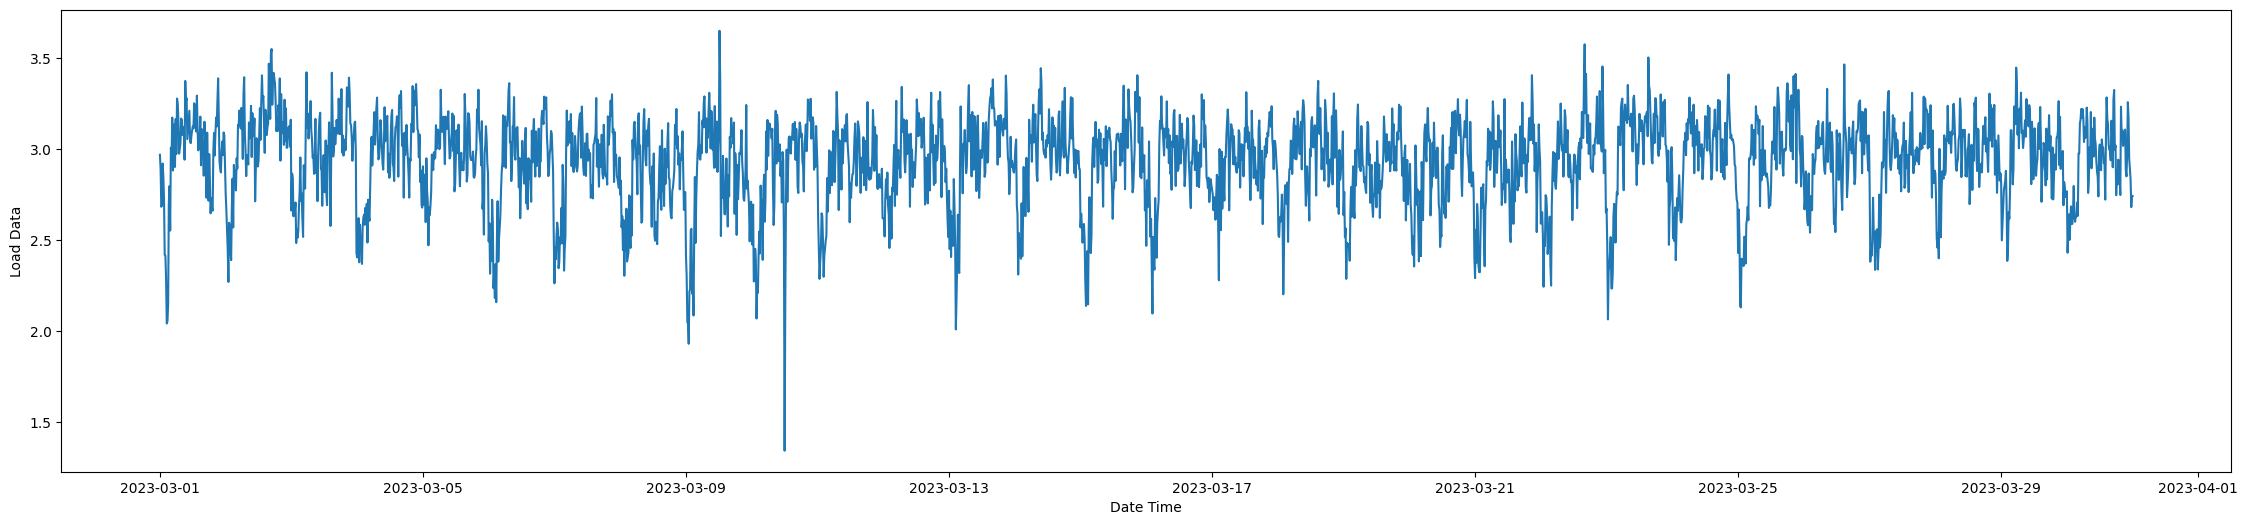

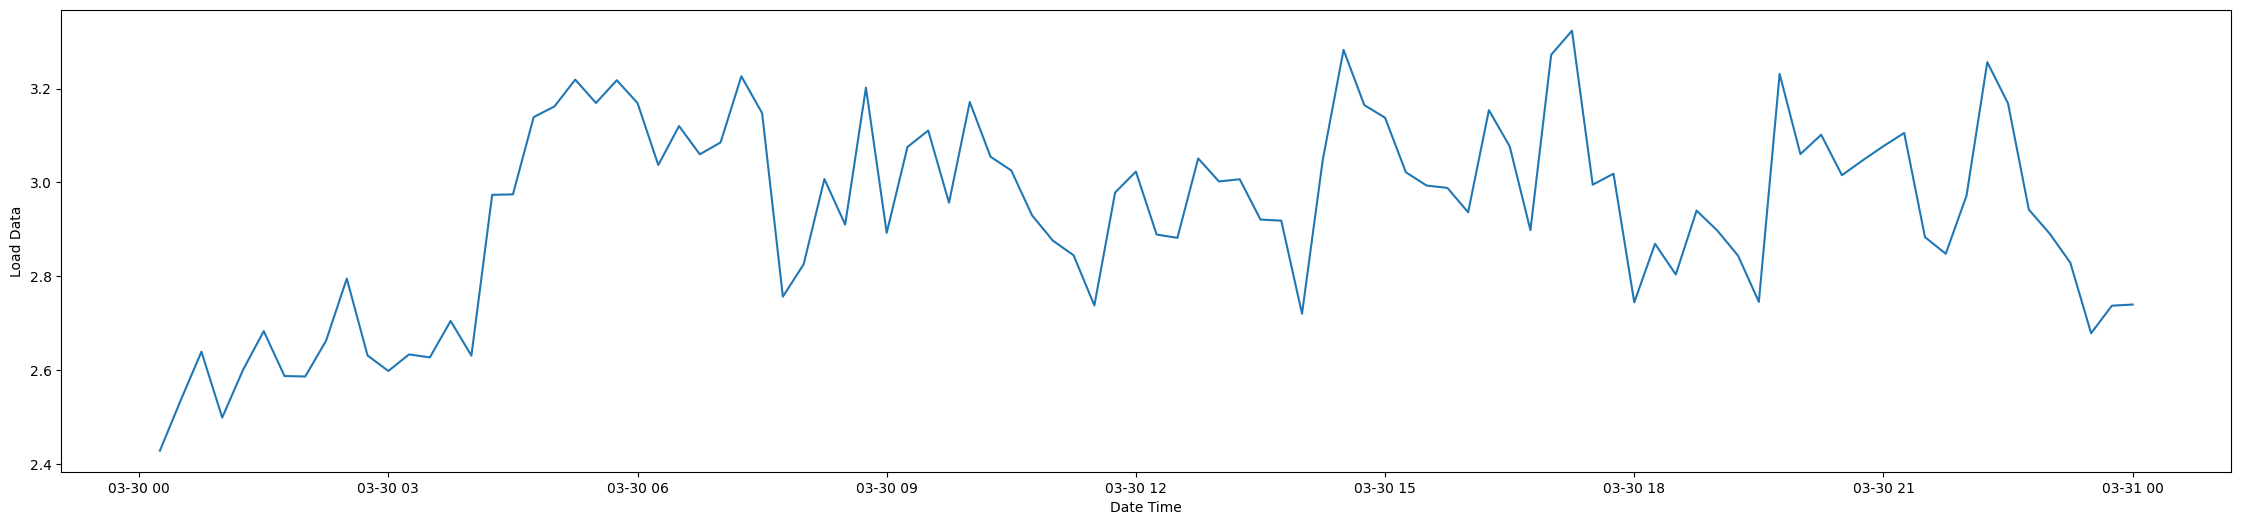

In [56]:
# plot the log load data of one month
df_month = plot_data(df2, '2023-03-01', '2023-03-31', 'month.png', columns=['log_load'])
df_day = plot_data(df2, '2023-03-30 00:15:00', '2023-03-31 00:00:00', 'day_1.png', columns=['log_load'])


In [63]:
model_mean_pred = df2['log_load'].mean()
df2['model_mean_pred'] =  np.exp(model_mean_pred)

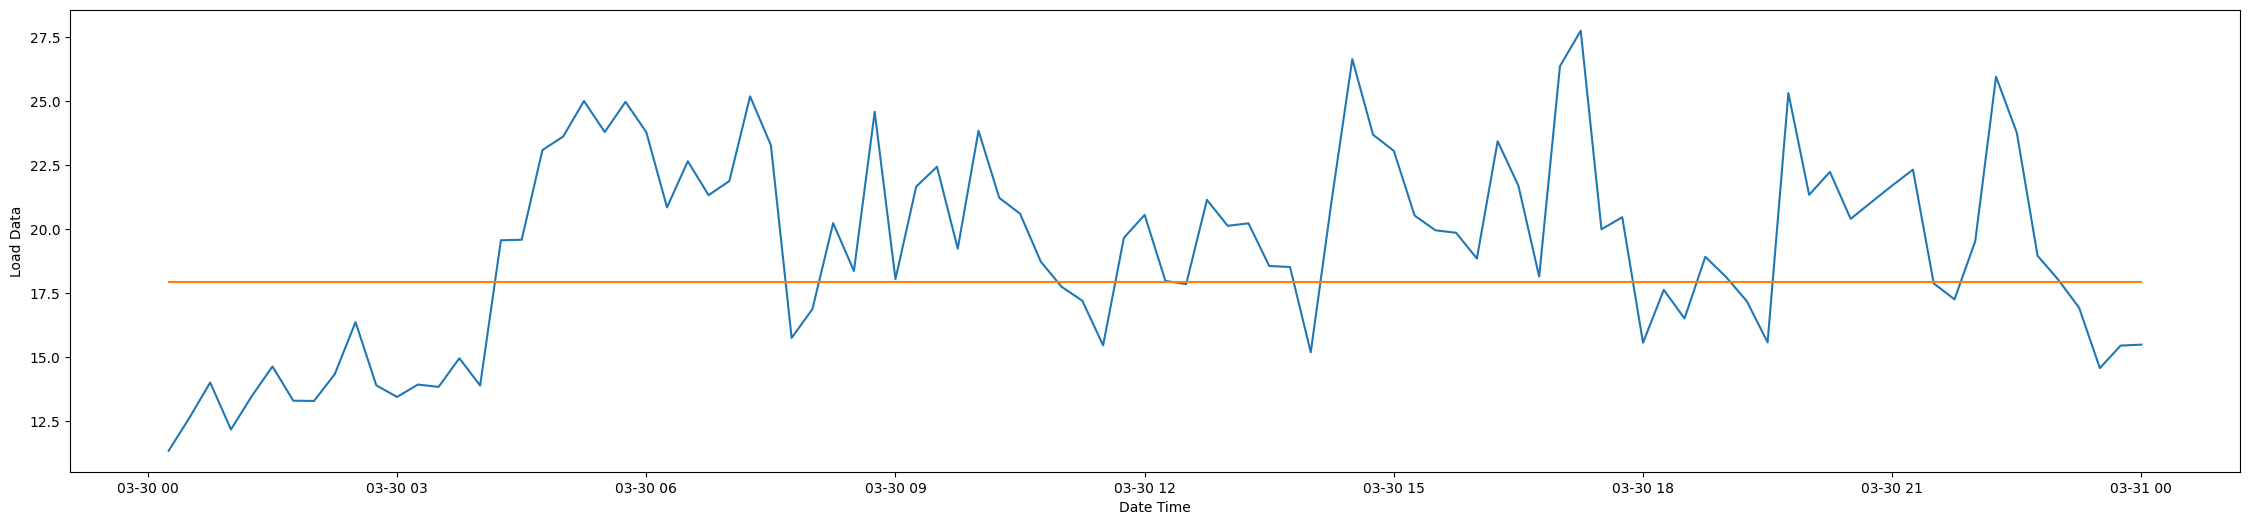

,load,date,log_load,model_mean_pred
data,,,,
2023-03-30 00:15:00,11.34704,2023-03-30 00:15:00,2.428957,17.937856
2023-03-30 00:30:00,12.63096,2023-03-30 00:30:00,2.536151,17.937856
2023-03-30 00:45:00,14.01004,2023-03-30 00:45:00,2.639774,17.937856
2023-03-30 01:00:00,12.17592,2023-03-30 01:00:00,2.499460,17.937856
2023-03-30 01:15:00,13.47468,2023-03-30 01:15:00,2.600812,17.937856
...,...,...,...,...
2023-03-30 23:00:00,18.01872,2023-03-30 23:00:00,2.891411,17.937856
2023-03-30 23:15:00,16.93144,2023-03-30 23:15:00,2.829172,17.937856
2023-03-30 23:30:00,14.57172,2023-03-30 23:30:00,2.679083,17.937856


In [65]:
# plot
plot_data(df2, '2023-03-30 00:15:00', '2023-03-31 00:00:00', 'day_1.png', columns=['load', 'model_mean_pred'])

In [66]:
# root mean square error
def RMSE(pred, actual):
    return np.sqrt(np.mean((pred - actual)**2))

# mean absolute percentage error
def MAPE(pred, actual):
    return np.mean(np.abs((pred - actual)/actual)) * 100

In [68]:
mean_rmse = RMSE(df2['model_mean_pred'], df2['load'])

In [71]:
result = pd.DataFrame({'Method':['Mean'], 'Forecast': [model_mean_pred],'RMSE':[mean_rmse]})

In [72]:
result

,Method,Forecast,RMSE
0,Mean,2.886913,4.521034


In [73]:
df2.dtypes

load                      float64
date               datetime64[ns]
log_load                  float64
model_mean_pred           float64
dtype: object

In [74]:
df2.date.min()

Timestamp('2022-04-01 00:15:00')

In [75]:
df2["time_index"] = df2.date - df2.date.min() #timedelta object

In [76]:
df2.head()

,load,date,log_load,model_mean_pred,time_index
data,,,,,
2022-04-01 00:15:00,16.07,2022-04-01 00:15:00,2.776954,17.937856,0 days 00:00:00
2022-04-01 00:30:00,13.75,2022-04-01 00:30:00,2.621039,17.937856,0 days 00:15:00
2022-04-01 00:45:00,13.13,2022-04-01 00:45:00,2.574900,17.937856,0 days 00:30:00
2022-04-01 01:00:00,10.36,2022-04-01 01:00:00,2.337952,17.937856,0 days 00:45:00
2022-04-01 01:15:00,9.96,2022-04-01 01:15:00,2.298577,17.937856,0 days 01:00:00


In [ ]:
linear_model = np.polyfit(np.arange(1,df2.shape[0]+1), df2['log_load'], 1)

In [91]:
# time delta
df2['Months'] = (df2['time_index'].dt.days/30).round(0).astype(int)
df2['min']  = df2['time_index'].dt.total_seconds()/60/15
df2['days'] = df2['time_index'].dt.days
df2['day_of_week'] = df2['date'].dt.dayofweek

In [92]:
df2.head()


,load,date,log_load,model_mean_pred,time_index,Months,15_min,days,day_of_week,min
data,,,,,,,,,,
2022-04-01 00:15:00,16.07,2022-04-01 00:15:00,2.776954,17.937856,0 days 00:00:00,0,0.0,0,4,0.0
2022-04-01 00:30:00,13.75,2022-04-01 00:30:00,2.621039,17.937856,0 days 00:15:00,0,1.0,0,4,1.0
2022-04-01 00:45:00,13.13,2022-04-01 00:45:00,2.574900,17.937856,0 days 00:30:00,0,2.0,0,4,2.0
2022-04-01 01:00:00,10.36,2022-04-01 01:00:00,2.337952,17.937856,0 days 00:45:00,0,3.0,0,4,3.0
2022-04-01 01:15:00,9.96,2022-04-01 01:15:00,2.298577,17.937856,0 days 01:00:00,0,4.0,0,4,4.0


In [115]:
df2.days.tail()

data
2023-07-23 23:00:00    478
2023-07-23 23:15:00    478
2023-07-23 23:30:00    478
2023-07-23 23:45:00    478
2023-07-24 00:00:00    478
Name: days, dtype: int64

In [122]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
# day data fit
day_data = df2.loc[df2['days'] == 1]
model_linear = smf.ols(formula='log_load ~ min', data=day_data).fit()

In [123]:
model_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_load   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     17.67
Date:                Mon, 06 Nov 2023   Prob (F-statistic):           5.98e-05
Time:                        17:39:44   Log-Likelihood:                 4.0640
No. Observations:                  96   AIC:                            -4.128
Df Residuals:                      94   BIC:                             1.001
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3629      0.126     18.728      0.000       2.112       2.613
min            0.0036      0.001      4.204      0.000       0.002       0.005
==============================================================================
Omnibus:                        1.745   Durbin-Watson:                   0.588
Prob(Omnibus):                  0.418   Jarque-Bera (JB):                1.616
Skew:                          -0.207   Prob(JB):                        0.446
Kurtosis:                       2.518   Cond. No.                         771.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [124]:
model_linear.params

Intercept    2.362906
min          0.003629
dtype: float64

In [125]:
c = model_linear.params[0]
m = model_linear.params[1]

C:\Users\Admin\AppData\Local\Temp\ipykernel_19292\4272506800.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Admin\AppData\Local\Temp\ipykernel_19292\4272506800.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [126]:
model_linear_pred = model_linear.predict()

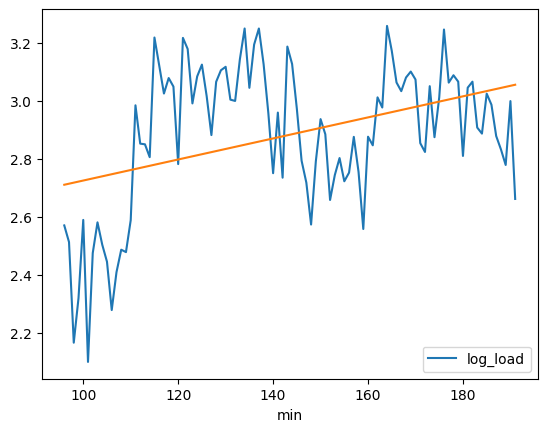

In [127]:
day_data.plot(x= 'min', y='log_load' )
plt.plot(day_data['min'], model_linear_pred)

In [172]:
# function to take a day data and return the linear model prediction plot

def linear_model_plot(day_data,RMSE):
    model_linear = smf.ols(formula='log_load ~ min', data=day_data).fit()
    model_linear_pred = model_linear.predict()
    day_data['linear_model_pred'] = np.exp(model_linear_pred)
    mean = day_data['log_load'].mean()
    day_data['mean'] =np.exp(mean)
    rmse_mean = RMSE(day_data['load'], day_data['linear_model_pred'])
    rmse_linear = RMSE(day_data['load'], day_data['mean'])
    print('RMSE of mean model: {}, RMSE of Linear Model: {}'.format(rmse_mean, rmse_linear))
    plt.figure(figsize=(28,4))
    plt.plot(day_data['min'], day_data['load'] )
    plt.plot(day_data['min'], day_data['mean'] )
    plt.plot(day_data['min'], day_data['linear_model_pred'], '-' )
    plt.show()
    return mean, model_linear_pred

RMSE of mean model: 4.007022784100032, RMSE of Linear Model: 4.093463096482038


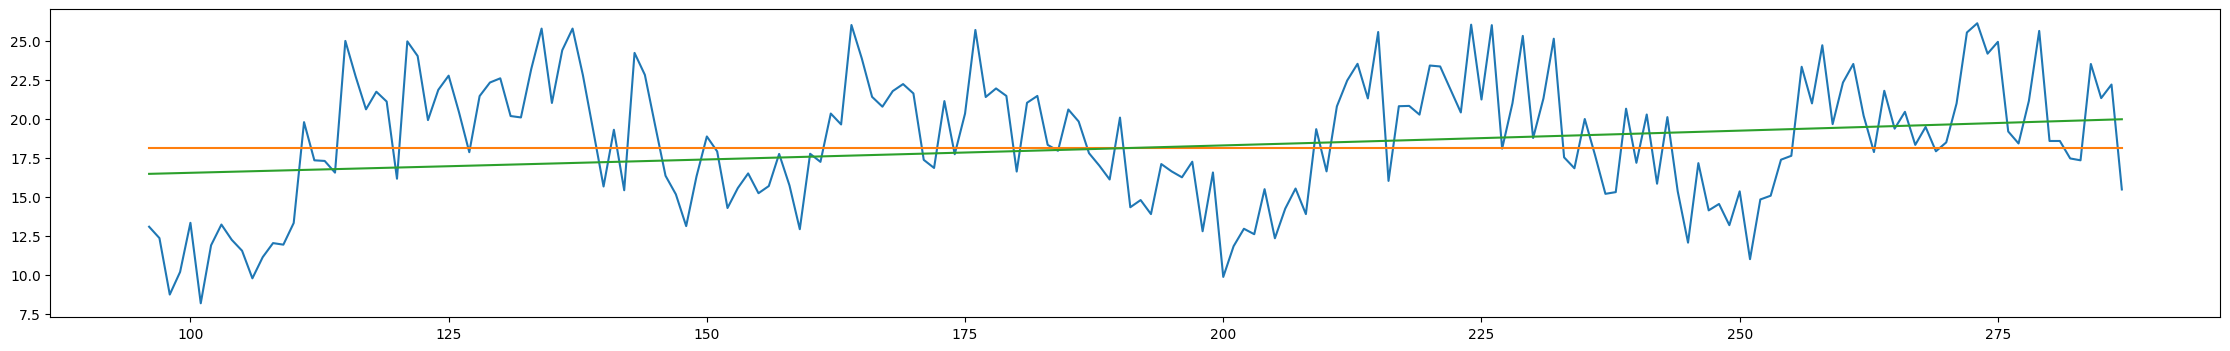

RMSE of mean model: 3.4761647624379557, RMSE of Linear Model: 3.4770868497599206


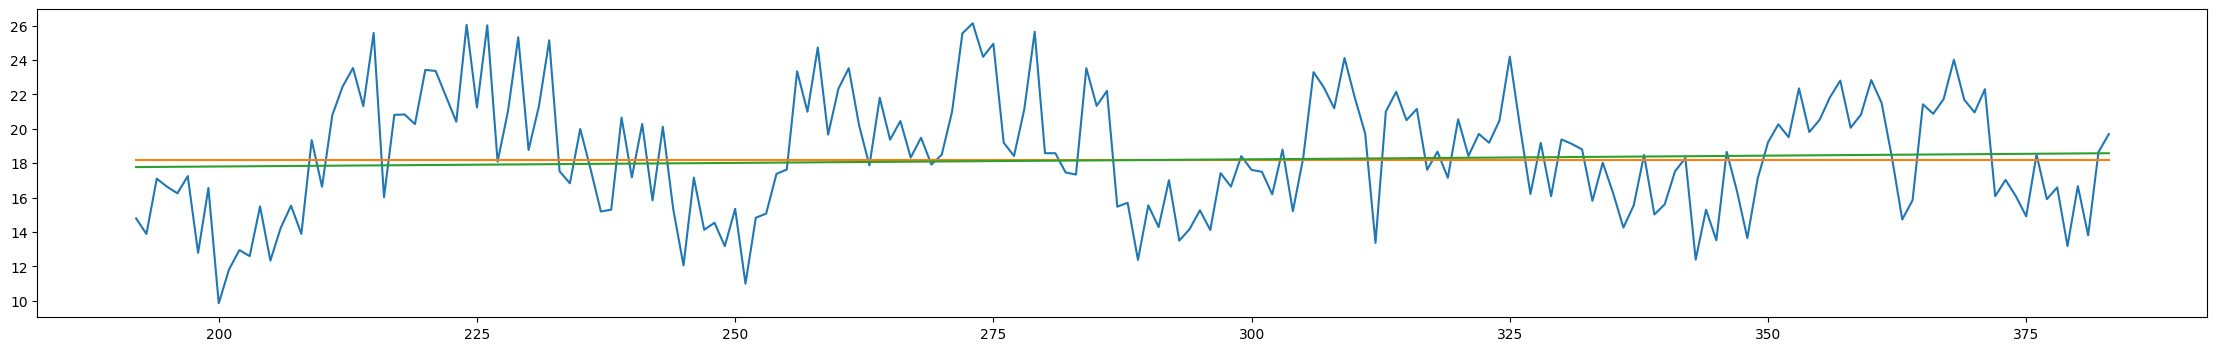

RMSE of mean model: 3.7588630844039894, RMSE of Linear Model: 3.7893425467059347


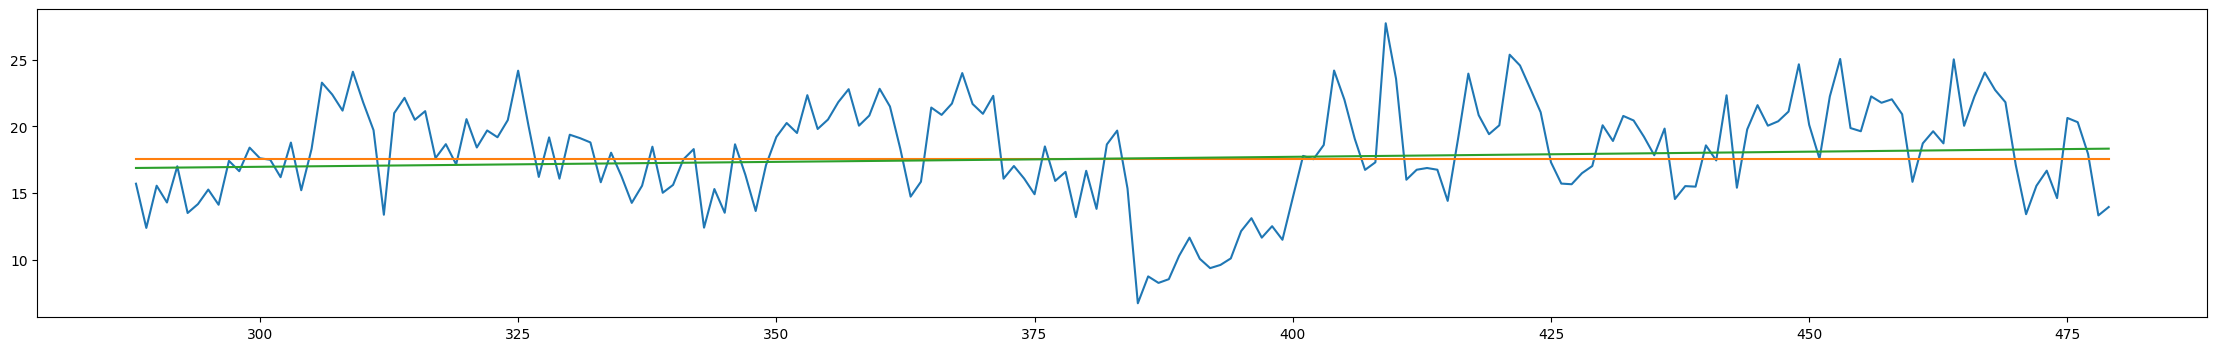

RMSE of mean model: 4.0883800034563755, RMSE of Linear Model: 4.21659989044451


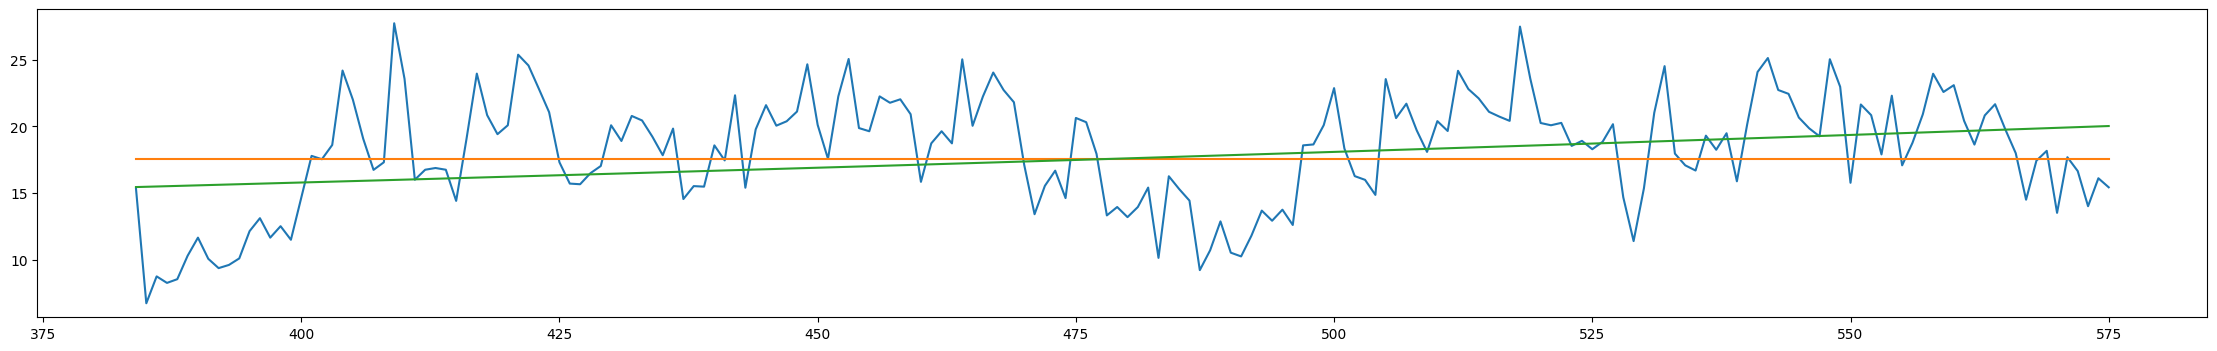

RMSE of mean model: 4.333619747988298, RMSE of Linear Model: 4.363446844283131


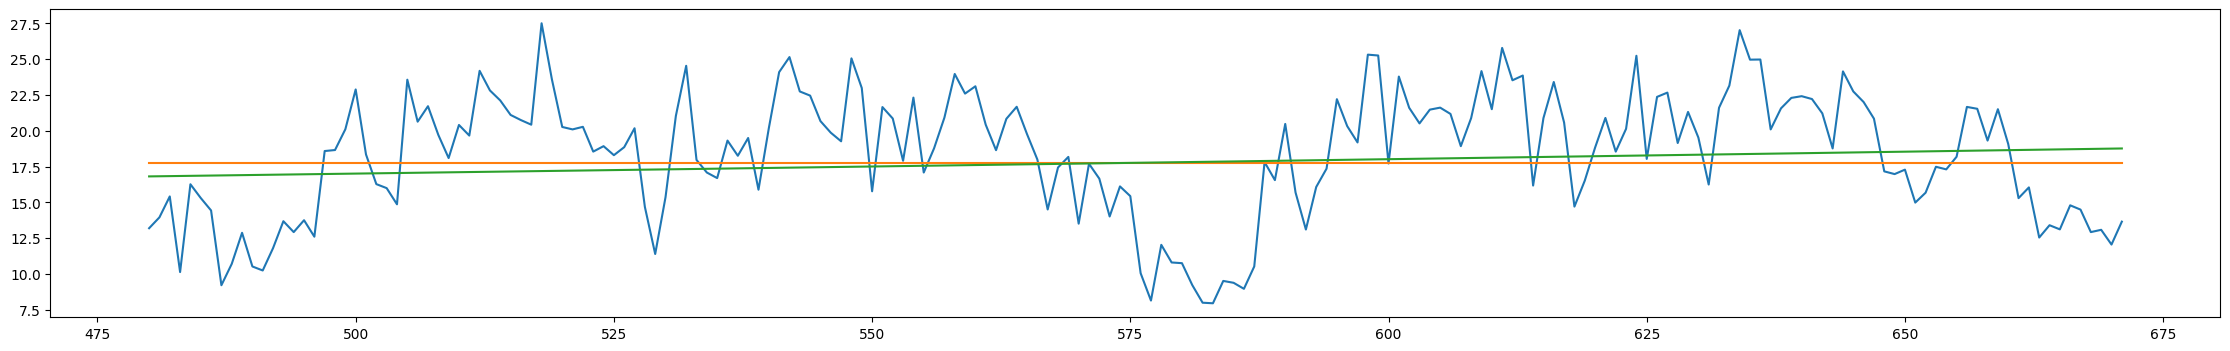

In [173]:
# plot the linear model prediction for the first 5 days individually
import warnings
warnings.filterwarnings('ignore')

for i in range(1,6):
    day_data = df2.loc[df2['days'].isin([i, i+1])]
    linear_model_plot(day_data, RMSE)



RMSE of mean model: 4.321366008969314, RMSE of Linear Model: 4.322263204984546


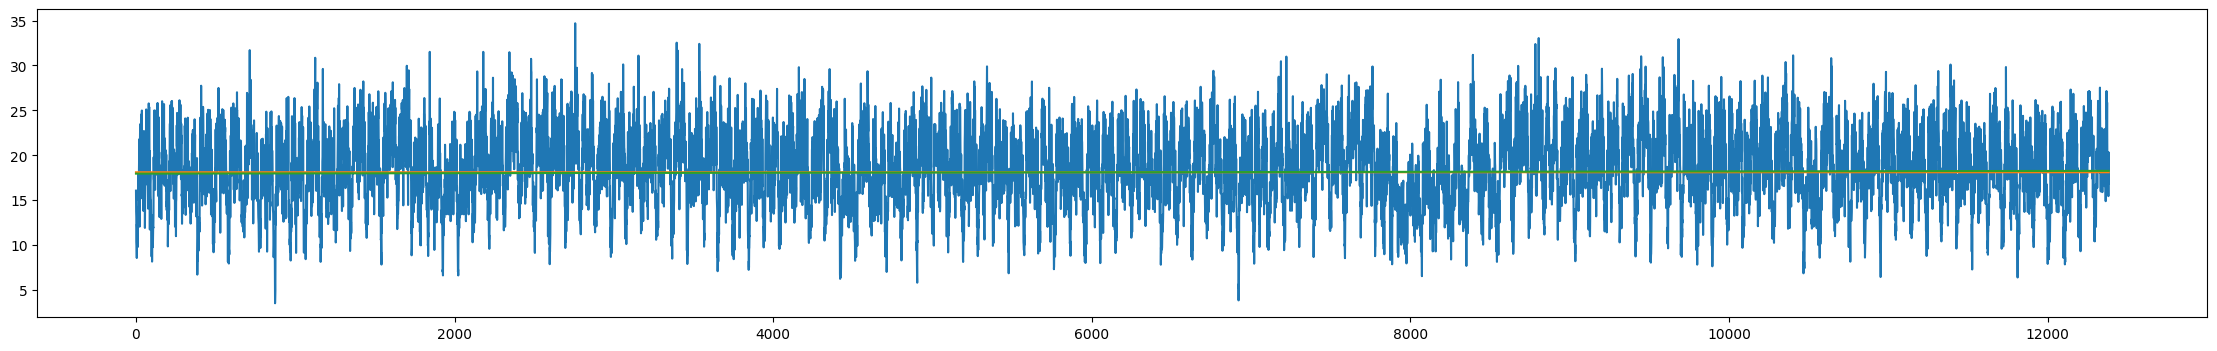

(2.8967971978006593,
 array([2.8883164 , 2.88831777, 2.88831914, ..., 2.90527526, 2.90527663,
        2.905278  ]))

In [200]:
month_data = df2.loc[df2['days'] <= 128]
linear_model_plot(month_data, RMSE)

In [208]:
# linear model with regressor
month_data = df2.loc[df2['days'] <= 4*28]
model_linear = smf.ols(formula='log_load ~ min + C(day_of_week)', data=month_data).fit()

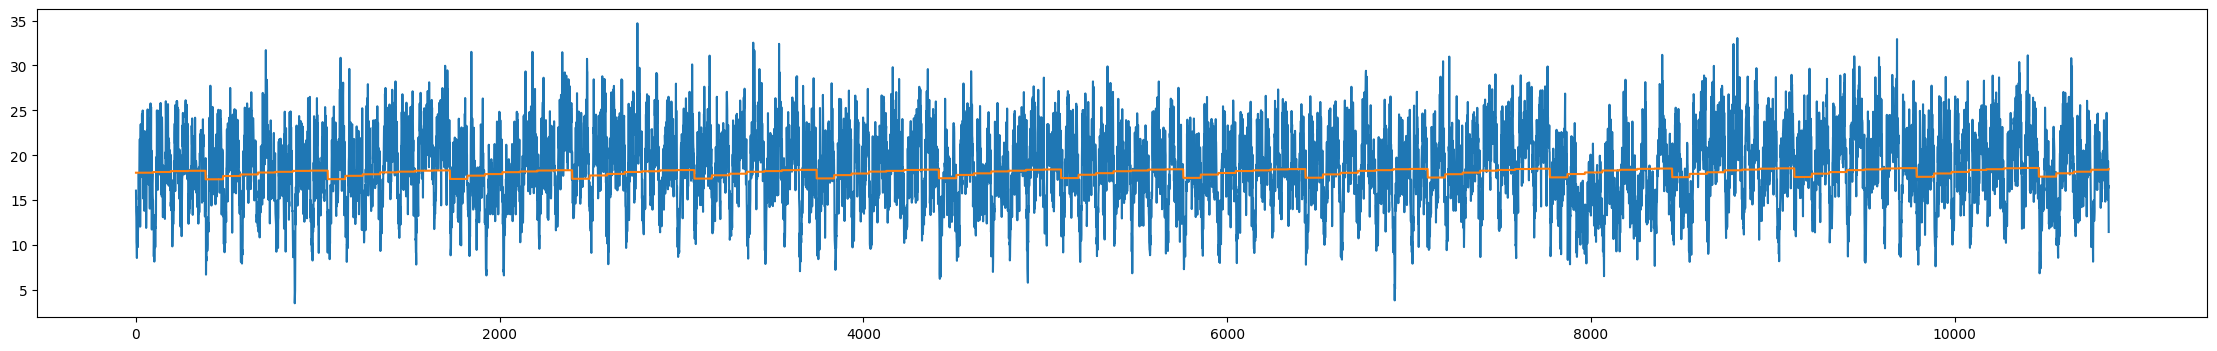

In [209]:
month_data['linear_model_pred'] = np.exp(model_linear.predict())
plt.figure(figsize=(28,4))
plt.plot(month_data['min'], month_data['load'] )
plt.plot(month_data['min'], month_data['linear_model_pred'], '-' )
plt.show()


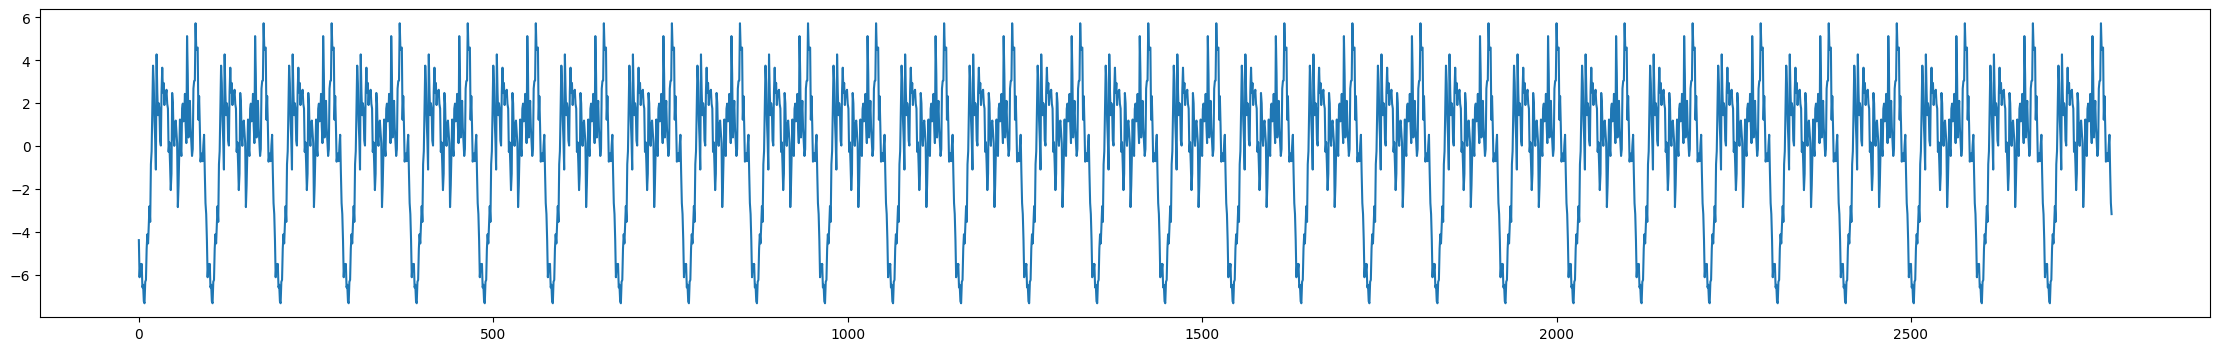

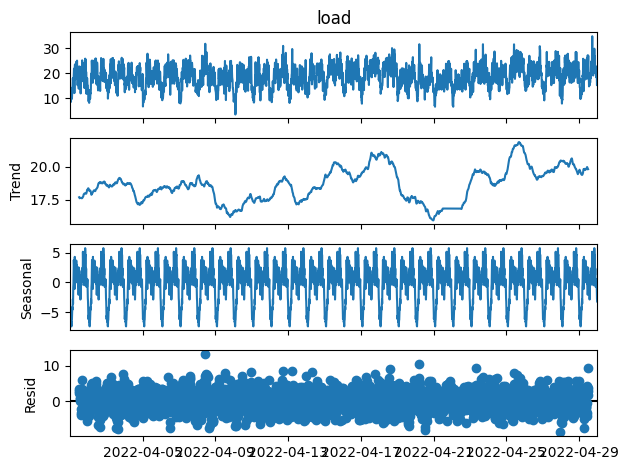

In [225]:
import pandas as pd
import statsmodels.api as sm

# Assuming df is your DataFrame and 'time' is your time column
# 'output_var' is the column you want to analyze
# df2['time'] = pd.to_datetime(df['time'])
# df.set_index('time', inplace=True)

# Perform time series decomposition
month_data = df2.loc[df2['days'] <= 28]
decomposition = sm.tsa.seasonal_decompose(month_data['load'], model='additive', period = 4*24)

# Plot the original data, the trend, the seasonality, and the residuals 
plt.figure(figsize=(28,4))
plt.plot( month_data['min'], decomposition.seasonal ,label='Trend')
decomposition.plot()
plt.show()